# IJava — Quick reference and magics demo

Concise walkthrough showing IJava features and magics. This notebook uses `%%compile` for compilation and demonstrates the primary line and cell magics (first alias for each).

## Basic Java
Run a simple Java expression to verify the kernel is active.

In [8]:
System.out.println("Hello from IJava quick demo");

Hello from IJava quick demo


## List magics
Show registered line and cell magics.

In [9]:
%listMagic

registered line magics: 
	- printerPrefix
	- jars
	- read
	- listMagic, list
	- listLineMagic
	- listCellMagic
	- maven, addMavenDependencies, addMavenDependency
	- printWithName
	- commonshellcmd
	- pom, loadFromPOM
	- cmd
	- addMavenRepo, mavenRepo
	- write
	- load
	- classpath
registered cell magics: 
	- javasrcInterfaceByName
	- myshell
	- write
	- commonshell
	- plantUMLFile
	- compile
	- javasrcMethodByName
	- shell
	- mycompile
	- javasrcClassByName
	- pom, loadFromPOM
	- timeIt, timeit, time
	- plantUML
	- javasrcMethodByAnnotationName


## Classpath & dependencies
Add Maven artifacts and jars to the runtime classpath.

In [10]:
%maven org.apache.commons:commons-text:1.10.0
%jars org.apache.commons:commons-lang3:3.12.0
import org.apache.commons.text.WordUtils;
System.out.println(WordUtils.capitalizeFully("iJava demo using maven/jars"));

Ijava Demo Using Maven/jars


## Compiler — `%%compile` (annotation-processor aware)
Use `%%compile` to compile sources with `javac` and run annotation processors (e.g., Lombok).

In [11]:
%maven org.projectlombok:lombok:1.18.42

In [12]:
%%compile com.example.Greeter -v
public class Greeter {
  private final String name;
  public Greeter(String name) { this.name = name; }
  public String greet() { return "Hello " + name; }
}

17:03:15.741 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.Greeter with debug=false and nowarn=false
17:03:15.742 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/Greeter.java
17:03:15.925 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
17:03:15.926 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.Greeter and added to classpath


In [13]:
import com.example.Greeter;
Greeter g = new Greeter("World");
System.out.println(g.greet());

Hello World


In [14]:
%%compile com.example.lombok.LombokExample -v
import lombok.Data;
import lombok.AllArgsConstructor;
public class LombokExample {
  @Data
  @AllArgsConstructor
  public static class Person {
    private final String name;
    private int age;
  }
  public static String test() {
    Person p = new Person("Alice", 30);
    return p.getName() + ":" + p.getAge();
  }
}

17:03:16.098 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.lombok.LombokExample with debug=false and nowarn=false
17:03:16.099 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/lombok/LombokExample.java
17:03:16.301 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
17:03:16.302 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.lombok.LombokExample and added to classpath


In [15]:
import com.example.lombok.LombokExample;
System.out.println(LombokExample.test());

Alice:30


## File IO magics
Write and read a small file using `%write` and `%read`.

In [24]:
%%write /tmp/example.txt
Hello from IJava file write

Write to /tmp/example.txt success.


In [25]:
%read /tmp/example.txt

## Shell magics
Run shell commands with `%%shell` or single-line `%cmd`.

In [26]:
%%shell
uname -a
echo $SHELL
pwd

Linux pc-bruno 6.17.12-300.fc43.x86_64 #1 SMP PREEMPT_DYNAMIC Sat Dec 13 05:06:24 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux
bash
/var/home/bruno/Documents/GitHub/Jupyter-Kernels/IJava/docs/notebooks


In [19]:
%cmd echo Single-line cmd via %cmd

Single-line cmd via %cmd


## Utilities
Demonstrate utility line magics: `%listLineMagic`, `%listCellMagic`, `%printerPrefix`, `%printWithName`, `%addMavenRepo`, `%pom`, `%load` (loads file into cell).

In [20]:
%listLineMagic

registered line magics: 
	- printerPrefix
	- jars
	- read
	- listMagic, list
	- listLineMagic
	- listCellMagic
	- maven, addMavenDependencies, addMavenDependency
	- printWithName
	- commonshellcmd
	- pom, loadFromPOM
	- cmd
	- addMavenRepo, mavenRepo
	- write
	- load
	- classpath


In [21]:
%listCellMagic

registered cell magics: 
	- javasrcInterfaceByName
	- myshell
	- write
	- commonshell
	- plantUMLFile
	- compile
	- javasrcMethodByName
	- shell
	- mycompile
	- javasrcClassByName
	- pom, loadFromPOM
	- timeIt, timeit, time
	- plantUML
	- javasrcMethodByAnnotationName


In [22]:
%printerPrefix MyDemoPrefix
%printWithName -h

Change printer prefix from "" to "MyDemoPrefix"
run %printWithName to switch


In [28]:
//%addMavenRepo https://repo1.maven.org/maven2/
//%pom

## PlantUML and timing
Render PlantUML and measure execution with `%%plantUML` and `%%timeit`.

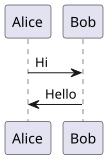

In [29]:
%%plantUML
@startuml
Alice -> Bob: Hi
Bob -> Alice: Hello
@enduml

In [30]:
%%timeit
int s = 0;
for (int i = 0; i < 10000; i++) s += i;
s

epoch 0: LongSummaryStatistics{count=5, sum=105, min=21, average=21,000000, max=21}
epoch 1: LongSummaryStatistics{count=5, sum=80, min=16, average=16,000000, max=16}
epoch 2: LongSummaryStatistics{count=5, sum=80, min=16, average=16,000000, max=16}
total: LongSummaryStatistics{count=15, sum=265, min=16, average=17,666667, max=21}


---
**Notes**: This notebook demonstrates the primary magics (first alias only). `%%compile` is used for all compilation examples to ensure annotation-processor support (Lombok).